# 04 EDA & Market Attractiveness Analysis

This notebook combines the cleaned World Bank KPI dataset from Notebook 2 with the Google Trends travel interest dataset from Notebook 3.

The goal is to explore the selected market indicators, validate the final KPI framework, and calculate a Market Attractiveness Score for the Top 30 GDP countries.

## 1. Business Objective

The objective is to identify countries with strong future potential for travel marketing investment.

The final framework focuses on five included indicators: tourism activity, economic growth, digital readiness, online travel demand, and market size.

Additional indicators such as Tourism Receipts, PPP Conversion Factor, and GDP per Capita were evaluated during the project but excluded from the final weighted score based on data coverage or methodology concerns.

## 2. Import Libraries

We start by importing the libraries needed for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 3. Load Final Datasets

This notebook uses two final CSV outputs from the previous notebooks:

| File | Source Notebook | Purpose |
|---|---|---|
| `market_kpis.csv` | Notebook 2 | Cleaned World Bank market KPIs |
| `selected_countries_gt_travel_scores_2024.csv` | Notebook 3 | Google Trends travel interest score |

Note: The Google Trends file name includes 2024, but the data was collected using the latest 12 months at the time of extraction. It should be interpreted as recent travel search interest, not calendar year 2024.

In [2]:
market_kpis_df = pd.read_csv("market_kpis.csv")
travel_interest_df = pd.read_csv("selected_countries_gt_travel_scores_2024.csv")

print("World Bank KPI dataset shape:", market_kpis_df.shape)
print("Google Trends dataset shape:", travel_interest_df.shape)

World Bank KPI dataset shape: (30, 20)
Google Trends dataset shape: (30, 4)


In [3]:
market_kpis_df.head()

,country,country_code,gdp_usd,gdp_year,tourism_arrivals,tourism_arrivals_year,gdp_growth,gdp_growth_year,internet_users_pct,internet_users_year,ppp_factor,ppp_factor_year,gdp_per_capita_usd,gdp_per_capita_year,population,population_year,urban_population_pct,urban_population_year,mobile_subscriptions_per_100,mobile_subscriptions_year
0,United States,USA,28750956130731.20,2024,165478000.00,2019,2.79,2024,92.73,2022,1.00,2022,84534.04,2024,340110988.00,2024,80.12,2024,113.19,2024
1,China,CHN,18743803170827.20,2024,162538000.00,2019,4.98,2024,75.61,2022,3.79,2022,13303.15,2024,1408975000.00,2024,65.89,2024,131.75,2024
2,Germany,DEU,4685592577804.69,2024,39563000.00,2019,-0.50,2024,91.63,2022,0.69,2022,56103.73,2024,83516593.00,2024,82.02,2024,129.15,2024
3,Japan,JPN,4027597523550.58,2024,31881000.00,2019,0.10,2024,84.92,2022,94.92,2022,32487.08,2024,123975371.00,2024,92.19,2024,NaN,2024
4,India,IND,3909891533858.08,2024,17914000.00,2019,6.49,2024,55.90,2022,20.49,2022,2694.74,2024,1450935791.00,2024,35.38,2024,79.35,2024


In [4]:
travel_interest_df.head()

,country,country_code,year,travel_interest_score
0,United States,USA,2024,50.00
1,China,CHN,2024,22.00
2,Germany,DEU,2024,14.00
3,Japan,JPN,2024,6.00
4,India,IND,2024,18.00


## 4. Initial Dataset Validation

Before merging the datasets, we check column names and missing values.

This step helps confirm that the previous notebooks produced the expected outputs.

In [5]:
print("World Bank KPI columns:")
print(market_kpis_df.columns.tolist())

print()

print("Google Trends columns:")
print(travel_interest_df.columns.tolist())

World Bank KPI columns:
['country', 'country_code', 'gdp_usd', 'gdp_year', 'tourism_arrivals', 'tourism_arrivals_year', 'gdp_growth', 'gdp_growth_year', 'internet_users_pct', 'internet_users_year', 'ppp_factor', 'ppp_factor_year', 'gdp_per_capita_usd', 'gdp_per_capita_year', 'population', 'population_year', 'urban_population_pct', 'urban_population_year', 'mobile_subscriptions_per_100', 'mobile_subscriptions_year']

Google Trends columns:
['country', 'country_code', 'year', 'travel_interest_score']


In [6]:
print("World Bank missing values:")
print(market_kpis_df.isna().sum())

print()

print("Google Trends missing values:")
print(travel_interest_df.isna().sum())

World Bank missing values:
country                         0
country_code                    0
gdp_usd                         0
gdp_year                        0
tourism_arrivals                0
tourism_arrivals_year           0
gdp_growth                      0
gdp_growth_year                 0
internet_users_pct              0
internet_users_year             0
ppp_factor                      0
ppp_factor_year                 0
gdp_per_capita_usd              0
gdp_per_capita_year             0
population                      0
population_year                 0
urban_population_pct            0
urban_population_year           0
mobile_subscriptions_per_100    2
mobile_subscriptions_year       0
dtype: int64

Google Trends missing values:
country                  0
country_code             0
year                     0
travel_interest_score    0
dtype: int64


## 5. KPI Data Year Coverage and Final Framework Decision

Before starting the exploratory data analysis, it is important to document the reporting period used for each indicator.

Not all indicators are available for the same year. Tourism Arrivals uses 2019 data because global tourism was significantly disrupted during the COVID period, making 2019 a cleaner pre disruption baseline for country comparison.

Google Trends follows a different methodology and represents search interest over the latest 12 month period at the time of extraction, rather than a single calendar year.

The final framework includes only KPIs with a clear business interpretation and suitable comparability across countries.

In [7]:
kpi_coverage_df = pd.DataFrame({
    "Metric": [
        "Tourism Arrivals",
        "Tourism Receipts",
        "GDP Growth",
        "Internet Penetration",
        "PPP Conversion Factor",
        "Travel Interest Score",
        "Population",
        "GDP per Capita"
    ],
    "Weight": [
        "15%",
        "0%",
        "25%",
        "25%",
        "0%",
        "25%",
        "10%",
        "0%"
    ],
    "Reporting Period": [
        "2019",
        "Not used in final score",
        "2024",
        "Latest available World Bank data",
        "Latest available World Bank data",
        "Latest 12 months from Google Trends extraction",
        "2024",
        "2024"
    ],
    "Status": [
        "Included",
        "Excluded due to incomplete coverage",
        "Included",
        "Included",
        "Excluded after EDA because the indicator is not directly comparable across currencies",
        "Included",
        "Included",
        "Supporting EDA only"
    ]
})

kpi_coverage_df

,Metric,Weight,Reporting Period,Status
0,Tourism Arrivals,15%,2019,Included
1,Tourism Receipts,0%,Not used in final score,Excluded due to incomplete coverage
2,GDP Growth,25%,2024,Included
3,Internet Penetration,25%,Latest available World Bank data,Included
4,PPP Conversion Factor,0%,Latest available World Bank data,Excluded after EDA because the indicator is no...
5,Travel Interest Score,25%,Latest 12 months from Google Trends extraction,Included
6,Population,10%,2024,Included
7,GDP per Capita,0%,2024,Supporting EDA only


## 6. Merge World Bank KPIs with Google Trends

The World Bank KPI dataset is merged with Google Trends travel interest data using `country` and `country_code`.

The result is the main dataset used for EDA, normalization, scoring, and ranking.

In [8]:
market_analysis_df = market_kpis_df.merge(
    travel_interest_df[["country", "country_code", "travel_interest_score"]],
    on=["country", "country_code"],
    how="left"
)

print("Merged dataset shape:", market_analysis_df.shape)
print("Number of countries:", market_analysis_df["country_code"].nunique())

market_analysis_df.head()

Merged dataset shape: (30, 21)
Number of countries: 30


,country,country_code,gdp_usd,gdp_year,tourism_arrivals,tourism_arrivals_year,gdp_growth,gdp_growth_year,internet_users_pct,internet_users_year,ppp_factor,ppp_factor_year,gdp_per_capita_usd,gdp_per_capita_year,population,population_year,urban_population_pct,urban_population_year,mobile_subscriptions_per_100,mobile_subscriptions_year,travel_interest_score
0,United States,USA,28750956130731.20,2024,165478000.00,2019,2.79,2024,92.73,2022,1.00,2022,84534.04,2024,340110988.00,2024,80.12,2024,113.19,2024,50.00
1,China,CHN,18743803170827.20,2024,162538000.00,2019,4.98,2024,75.61,2022,3.79,2022,13303.15,2024,1408975000.00,2024,65.89,2024,131.75,2024,22.00
2,Germany,DEU,4685592577804.69,2024,39563000.00,2019,-0.50,2024,91.63,2022,0.69,2022,56103.73,2024,83516593.00,2024,82.02,2024,129.15,2024,14.00
3,Japan,JPN,4027597523550.58,2024,31881000.00,2019,0.10,2024,84.92,2022,94.92,2022,32487.08,2024,123975371.00,2024,92.19,2024,NaN,2024,6.00
4,India,IND,3909891533858.08,2024,17914000.00,2019,6.49,2024,55.90,2022,20.49,2022,2694.74,2024,1450935791.00,2024,35.38,2024,79.35,2024,18.00


In [9]:
print("Missing values after merge:")
print(market_analysis_df.isna().sum())

Missing values after merge:
country                         0
country_code                    0
gdp_usd                         0
gdp_year                        0
tourism_arrivals                0
tourism_arrivals_year           0
gdp_growth                      0
gdp_growth_year                 0
internet_users_pct              0
internet_users_year             0
ppp_factor                      0
ppp_factor_year                 0
gdp_per_capita_usd              0
gdp_per_capita_year             0
population                      0
population_year                 0
urban_population_pct            0
urban_population_year           0
mobile_subscriptions_per_100    2
mobile_subscriptions_year       0
travel_interest_score           0
dtype: int64


## 7. Exploratory Data Analysis

This section reviews the cleaned indicators before applying the weighted framework.

The purpose is to understand the distribution of each KPI, identify potential issues, and validate whether the final framework makes business sense.

### 7.1 Summary Statistics

We summarize the main business metrics. Year columns are excluded from this table because they are metadata rather than KPI values.

In [10]:
eda_numeric_columns = [
    "gdp_usd",
    "tourism_arrivals",
    "gdp_growth",
    "internet_users_pct",
    "ppp_factor",
    "gdp_per_capita_usd",
    "population",
    "urban_population_pct",
    "mobile_subscriptions_per_100",
    "travel_interest_score"
]

eda_numeric_columns = [col for col in eda_numeric_columns if col in market_analysis_df.columns]

market_analysis_df[eda_numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_usd,30.00,3181712643684.40,5860753884425.24,526517658841.68,646616611914.13,1560985875466.58,2346528014591.13,28750956130731.20
tourism_arrivals,30.00,48342466.67,55090286.60,4905000.00,12890250.00,24850500.00,49024500.00,217877000.00
gdp_growth,30.00,2.15,1.84,-1.34,1.07,1.78,3.40,6.49
internet_users_pct,30.00,88.86,9.76,55.90,85.13,92.19,95.03,100.00
ppp_factor,30.00,199.72,903.25,0.56,0.72,1.90,9.53,4917.92
gdp_per_capita_usd,30.00,43755.04,29339.63,2694.74,15139.94,43244.21,56991.76,112894.95
population,30.00,163631731.33,353643315.20,5395790.00,13392328.75,50299952.50,114361193.50,1450935791.00
urban_population_pct,30.00,79.24,13.61,35.38,70.98,82.36,87.83,100.00
mobile_subscriptions_per_100,28.00,133.63,29.19,79.35,113.05,129.31,145.40,203.21
travel_interest_score,30.00,24.47,21.44,4.00,11.25,15.00,27.00,83.00


### 7.2 Top Countries by Final Framework KPIs

This section reviews the strongest countries for each included KPI before normalization and weighting.

In [11]:
framework_kpis_with_years = [
    ("tourism_arrivals", "tourism_arrivals_year"),
    ("gdp_growth", "gdp_growth_year"),
    ("internet_users_pct", "internet_users_year"),
    ("travel_interest_score", None),
    ("population", "population_year")
]

for kpi, year_col in framework_kpis_with_years:
    print()

    if year_col and year_col in market_analysis_df.columns:
        available_years = sorted(market_analysis_df[year_col].dropna().unique())
        print(f"Top 10 countries by {kpi}. Reporting year(s): {available_years}")
        display_columns = ["country", "country_code", year_col, kpi]
    else:
        print(f"Top 10 countries by {kpi}. Reporting period: Latest 12 months from Google Trends extraction")
        display_columns = ["country", "country_code", kpi]

    display(
        market_analysis_df[display_columns]
        .sort_values(by=kpi, ascending=False)
        .head(10)
    )


Top 10 countries by tourism_arrivals. Reporting year(s): [np.int64(2019)]


,country,country_code,tourism_arrivals_year,tourism_arrivals
6,France,FRA,2019,217877000.00
0,United States,USA,2019,165478000.00
1,China,CHN,2019,162538000.00
14,Spain,ESP,2019,126170000.00
12,Mexico,MEX,2019,97406000.00
7,Italy,ITA,2019,95399000.00
20,Poland,POL,2019,88515000.00
16,Turkiye,TUR,2019,51747000.00
5,United Kingdom,GBR,2019,40857000.00
29,Thailand,THA,2019,39916000.00



Top 10 countries by gdp_growth. Reporting year(s): [np.int64(2024)]


,country,country_code,gdp_growth_year,gdp_growth
4,India,IND,2024,6.49
15,Indonesia,IDN,2024,5.03
1,China,CHN,2024,4.98
26,Singapore,SGP,2024,4.39
10,Russian Federation,RUS,2024,4.34
25,United Arab Emirates,ARE,2024,3.99
14,Spain,ESP,2024,3.46
9,Brazil,BRA,2024,3.42
16,Turkiye,TUR,2024,3.33
20,Poland,POL,2024,3.03



Top 10 countries by internet_users_pct. Reporting year(s): [np.int64(2022)]


,country,country_code,internet_users_year,internet_users_pct
17,Saudi Arabia,SAU,2022,100.00
25,United Arab Emirates,ARE,2022,100.00
11,"Korea, Rep.",KOR,2022,97.17
19,Switzerland,CHE,2022,96.45
13,Australia,AUS,2022,96.12
26,Singapore,SGP,2022,95.95
5,United Kingdom,GBR,2022,95.47
23,Ireland,IRL,2022,95.04
24,Sweden,SWE,2022,95.01
14,Spain,ESP,2022,94.49



Top 10 countries by travel_interest_score. Reporting period: Latest 12 months from Google Trends extraction


,country,country_code,travel_interest_score
26,Singapore,SGP,83.00
5,United Kingdom,GBR,69.00
13,Australia,AUS,63.00
23,Ireland,IRL,59.00
0,United States,USA,50.00
8,Canada,CAN,50.00
25,United Arab Emirates,ARE,46.00
11,"Korea, Rep.",KOR,28.00
19,Switzerland,CHE,24.00
1,China,CHN,22.00



Top 10 countries by population. Reporting year(s): [np.int64(2024)]


,country,country_code,population_year,population
4,India,IND,2024,1450935791.00
1,China,CHN,2024,1408975000.00
0,United States,USA,2024,340110988.00
15,Indonesia,IDN,2024,283487931.00
9,Brazil,BRA,2024,211998573.00
10,Russian Federation,RUS,2024,143533851.00
12,Mexico,MEX,2024,130861007.00
3,Japan,JPN,2024,123975371.00
16,Turkiye,TUR,2024,85518661.00
2,Germany,DEU,2024,83516593.00


### 7.3 Supporting Indicators Reviewed During EDA

The following indicators were explored but are not included in the final weighted score.

Tourism Receipts was removed due to incomplete coverage. PPP Conversion Factor was excluded because the selected indicator is expressed in local currency units per international dollar, making direct cross-country comparison problematic. GDP per Capita was kept as supporting analysis but excluded from the final score to avoid over favoring mature high income economies.

In [15]:
supporting_columns = [
    "country",
    "country_code",
    "ppp_factor",
    "gdp_per_capita_usd",
    "gdp_usd",
    "urban_population_pct",
    "mobile_subscriptions_per_100"
]

supporting_columns = [col for col in supporting_columns if col in market_analysis_df.columns]

market_analysis_df[supporting_columns].head(10)

,country,country_code,ppp_factor,gdp_per_capita_usd,gdp_usd,urban_population_pct,mobile_subscriptions_per_100
0,United States,USA,1.00,84534.04,28750956130731.20,80.12,113.19
1,China,CHN,3.79,13303.15,18743803170827.20,65.89,131.75
2,Germany,DEU,0.69,56103.73,4685592577804.69,82.02,129.15
3,Japan,JPN,94.92,32487.08,4027597523550.58,92.19,NaN
4,India,IND,20.49,2694.74,3909891533858.08,35.38,79.35
5,United Kingdom,GBR,0.63,53246.37,3686033044482.13,83.24,121.64
6,France,FRA,0.68,46103.08,3160442622465.08,78.80,NaN
7,Italy,ITA,0.59,40385.34,2380825077243.59,69.60,132.58
8,Canada,CAN,1.15,54340.35,2243636826633.76,82.70,94.11
9,Brazil,BRA,2.41,10310.55,2185821648943.86,87.90,101.93


### 7.4 PPP Validation

PPP Conversion Factor was initially considered as a proxy for price competitiveness. However, the values are expressed in local currency units per international dollar.

Because currencies have very different unit scales, the indicator is not suitable for direct Min Max normalization across countries. This is why PPP receives a 0% weight in the final framework.

In [16]:
if "ppp_factor" in market_analysis_df.columns:
    market_analysis_df[["country", "ppp_factor"]].sort_values("ppp_factor", ascending=False).head(10)

### 7.5 GDP per Capita Validation

GDP per Capita was reviewed as a possible proxy for consumer wealth.

It is useful as supporting context, but it is excluded from the final score because it can over favor mature high income economies. The business objective is to identify future market growth opportunities, not only the wealthiest countries.

In [17]:
if "gdp_per_capita_usd" in market_analysis_df.columns:
    market_analysis_df[
        ["country", "gdp_per_capita_usd"]
    ].sort_values("gdp_per_capita_usd", ascending=False).head(10)

### 7.6 Correlation Matrix

The correlation matrix helps identify relationships between the main business indicators.

Only numerical KPI values are included. Year columns are excluded.

In [18]:
correlation_columns = [
    "tourism_arrivals",
    "gdp_growth",
    "internet_users_pct",
    "travel_interest_score",
    "population",
    "gdp_per_capita_usd",
    "ppp_factor"
]

correlation_columns = [col for col in correlation_columns if col in market_analysis_df.columns]

correlation_matrix = market_analysis_df[correlation_columns].corr()
correlation_matrix

,tourism_arrivals,gdp_growth,internet_users_pct,travel_interest_score,population,gdp_per_capita_usd,ppp_factor
tourism_arrivals,1.00,0.11,-0.17,-0.11,0.26,-0.10,-0.13
gdp_growth,0.11,1.00,-0.49,0.15,0.59,-0.29,0.29
internet_users_pct,-0.17,-0.49,1.00,0.39,-0.73,0.64,-0.41
travel_interest_score,-0.11,0.15,0.39,1.00,-0.09,0.63,-0.08
population,0.26,0.59,-0.73,-0.09,1.00,-0.40,0.06
gdp_per_capita_usd,-0.10,-0.29,0.64,0.63,-0.40,1.00,-0.26
ppp_factor,-0.13,0.29,-0.41,-0.08,0.06,-0.26,1.00


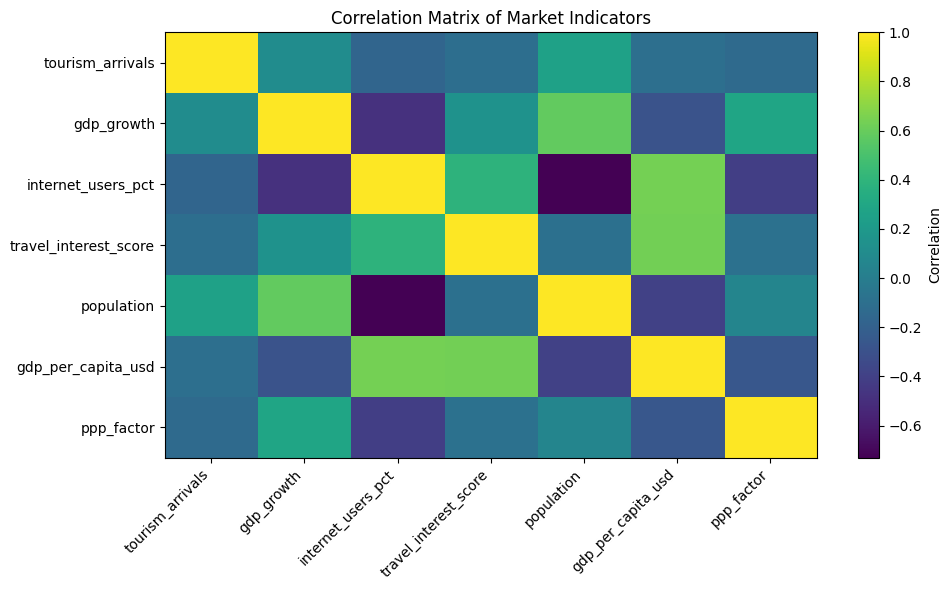

In [19]:
plt.figure(figsize=(10, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Matrix of Market Indicators")
plt.tight_layout()
plt.show()

### 7.7 KPI Distributions

The following charts show how the included framework KPIs are distributed across the selected countries.

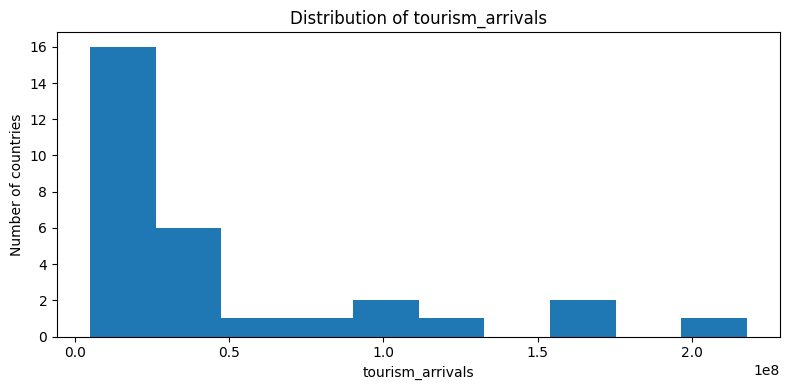

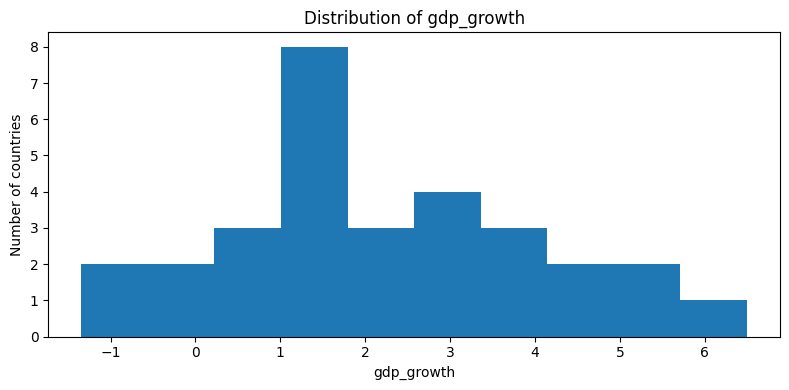

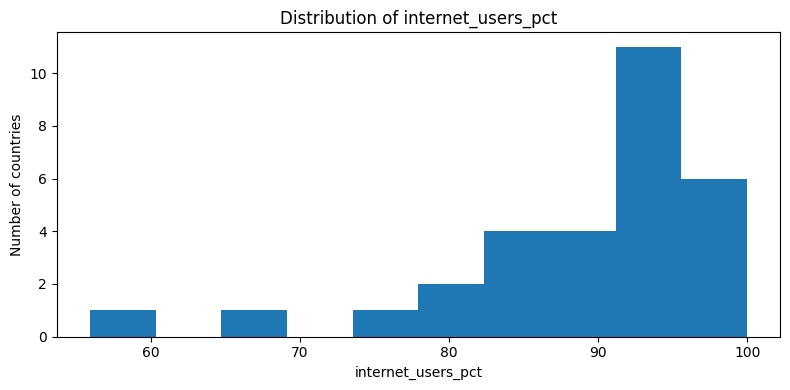

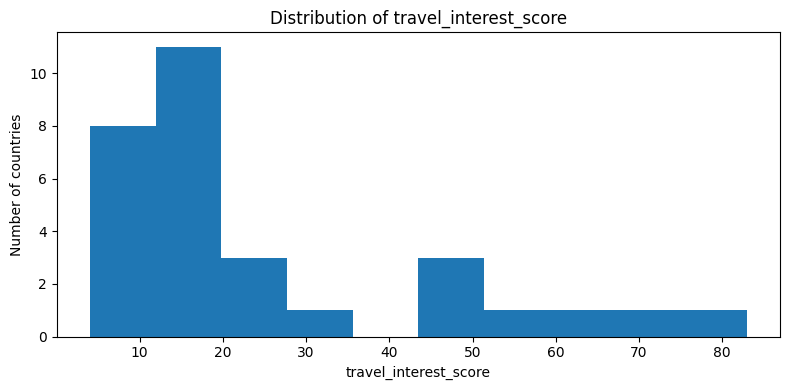

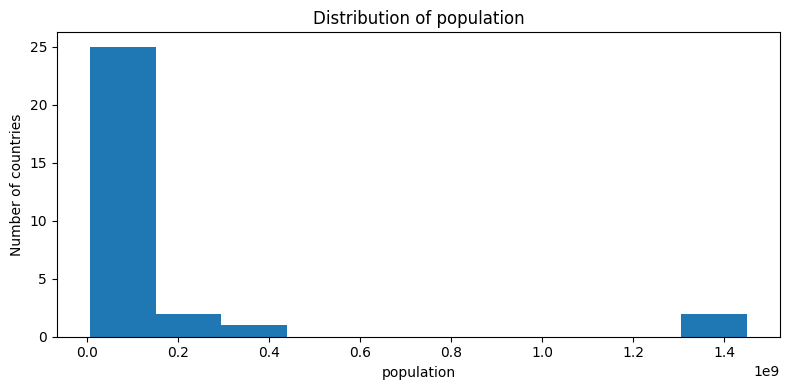

In [20]:
for col in ["tourism_arrivals", "gdp_growth", "internet_users_pct", "travel_interest_score", "population"]:
    plt.figure(figsize=(8, 4))
    plt.hist(market_analysis_df[col].dropna(), bins=10)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of countries")
    plt.tight_layout()
    plt.show()

## 8. KPI Normalization

The selected KPIs use different units and scales. For example, population is measured in people, GDP growth is a percentage, and travel interest is a Google Trends score.

To make them comparable, Min Max normalization is applied. This rescales every included KPI between 0 and 1.

Only KPIs with a positive final weight are normalized for the final Market Attractiveness Score.

In [21]:
def min_max_scale(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return series * 0

    return (series - minimum) / (maximum - minimum)

framework_kpis = [
    "tourism_arrivals",
    "gdp_growth",
    "internet_users_pct",
    "travel_interest_score",
    "population"
]

for col in framework_kpis:
    market_analysis_df[f"{col}_normalized"] = min_max_scale(market_analysis_df[col])

market_analysis_df[
    ["country"] + [f"{col}_normalized" for col in framework_kpis]
].head()

,country,tourism_arrivals_normalized,gdp_growth_normalized,internet_users_pct_normalized,travel_interest_score_normalized,population_normalized
0,United States,0.75,0.53,0.84,0.58,0.23
1,China,0.74,0.81,0.45,0.23,0.97
2,Germany,0.16,0.11,0.81,0.13,0.05
3,Japan,0.13,0.18,0.66,0.03,0.08
4,India,0.06,1.00,0.00,0.18,1.00


## 9. Market Attractiveness Framework

The final score applies the agreed business weights:

| Metric | Weight |
|---|---:|
| Tourism Arrivals | 15% |
| Tourism Receipts | 0% |
| GDP Growth | 25% |
| Internet Penetration | 25% |
| PPP Conversion Factor | 0% |
| Travel Interest Score | 25% |
| Population | 10% |
| GDP per Capita | 0% |

The included weights sum to 100%.

In [22]:
weights = {
    "tourism_arrivals_normalized": 0.15,
    "gdp_growth_normalized": 0.25,
    "internet_users_pct_normalized": 0.25,
    "travel_interest_score_normalized": 0.25,
    "population_normalized": 0.10
}

market_analysis_df["market_attractiveness_score"] = 0

for col, weight in weights.items():
    market_analysis_df["market_attractiveness_score"] += market_analysis_df[col] * weight

market_analysis_df["market_attractiveness_score"] = market_analysis_df["market_attractiveness_score"] * 100

market_analysis_df = market_analysis_df.sort_values(
    "market_attractiveness_score",
    ascending=False
).reset_index(drop=True)

market_analysis_df[["country", "country_code", "market_attractiveness_score"]].head(10)

,country,country_code,market_attractiveness_score
0,Singapore,SGP,66.99
1,United States,USA,62.25
2,China,CHN,57.84
3,United Arab Emirates,ARE,56.78
4,United Kingdom,GBR,53.85
5,Ireland,IRL,52.59
6,Australia,AUS,50.61
7,Spain,ESP,49.18
8,Canada,CAN,47.59
9,"Korea, Rep.",KOR,42.87


## 10. Score Contribution Breakdown

This section shows how much each KPI contributes to the final score.

This is useful for validating the ranking and explaining why each country appears in the final Top 10.

In [23]:
market_analysis_df["tourism_contribution"] = market_analysis_df["tourism_arrivals_normalized"] * 0.15
market_analysis_df["gdp_growth_contribution"] = market_analysis_df["gdp_growth_normalized"] * 0.25
market_analysis_df["internet_contribution"] = market_analysis_df["internet_users_pct_normalized"] * 0.25
market_analysis_df["travel_interest_contribution"] = market_analysis_df["travel_interest_score_normalized"] * 0.25
market_analysis_df["population_contribution"] = market_analysis_df["population_normalized"] * 0.10

contribution_columns = [
    "country",
    "tourism_contribution",
    "gdp_growth_contribution",
    "internet_contribution",
    "travel_interest_contribution",
    "population_contribution",
    "market_attractiveness_score"
]

market_analysis_df[contribution_columns].head(10)

,country,tourism_contribution,gdp_growth_contribution,internet_contribution,travel_interest_contribution,population_contribution,market_attractiveness_score
0,Singapore,0.01,0.18,0.23,0.25,0.00,66.99
1,United States,0.11,0.13,0.21,0.15,0.02,62.25
2,China,0.11,0.20,0.11,0.06,0.10,57.84
3,United Arab Emirates,0.01,0.17,0.25,0.13,0.00,56.78
4,United Kingdom,0.03,0.08,0.22,0.21,0.00,53.85
5,Ireland,0.00,0.13,0.22,0.17,0.00,52.59
6,Australia,0.00,0.09,0.23,0.19,0.00,50.61
7,Spain,0.09,0.15,0.22,0.03,0.00,49.18
8,Canada,0.02,0.09,0.22,0.15,0.00,47.59
9,"Korea, Rep.",0.01,0.11,0.23,0.08,0.00,42.87


## 11. Final Market Ranking

The countries are ranked by their final Market Attractiveness Score.

Higher scores indicate stronger overall attractiveness based on the selected weighted framework.

In [24]:
final_ranking_df = market_analysis_df[
    [
        "country",
        "country_code",
        "market_attractiveness_score",
        "tourism_arrivals",
        "gdp_growth",
        "internet_users_pct",
        "travel_interest_score",
        "population"
    ]
].copy()

final_ranking_df.head(10)

,country,country_code,market_attractiveness_score,tourism_arrivals,gdp_growth,internet_users_pct,travel_interest_score,population
0,Singapore,SGP,66.99,19116000.00,4.39,95.95,83.00,6036860.00
1,United States,USA,62.25,165478000.00,2.79,92.73,50.00,340110988.00
2,China,CHN,57.84,162538000.00,4.98,75.61,22.00,1408975000.00
3,United Arab Emirates,ARE,56.78,25282000.00,3.99,100.00,46.00,10986400.00
4,United Kingdom,GBR,53.85,40857000.00,1.13,95.47,69.00,69226000.00
5,Ireland,IRL,52.59,10951000.00,2.60,95.04,59.00,5395790.00
6,Australia,AUS,50.61,9466000.00,1.37,96.12,63.00,27196812.00
7,Spain,ESP,49.18,126170000.00,3.46,94.49,14.00,48848840.00
8,Canada,CAN,47.59,32430000.00,1.55,94.00,50.00,41288599.00
9,"Korea, Rep.",KOR,42.87,17503000.00,2.00,97.17,28.00,51751065.00


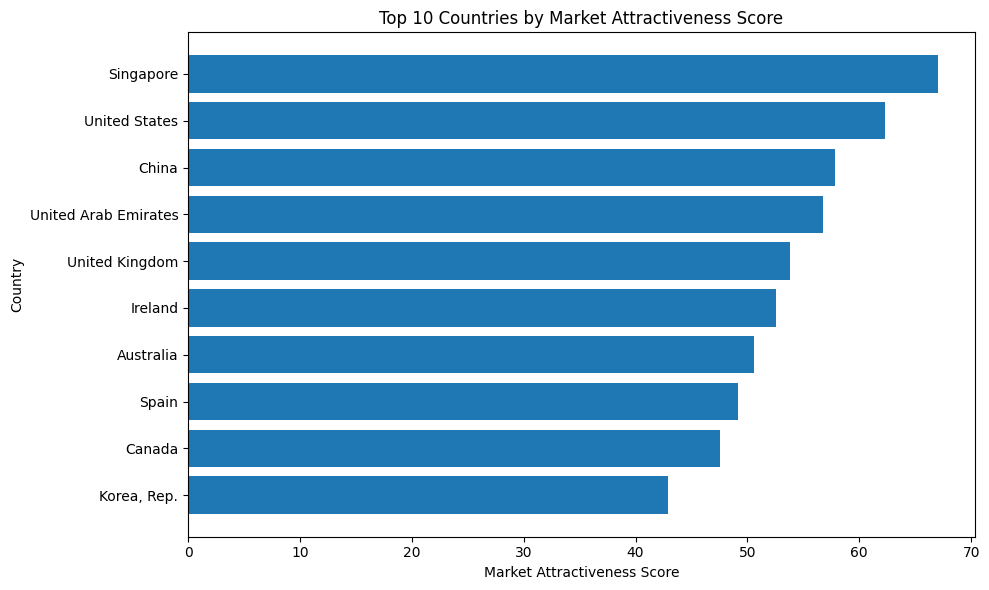

In [25]:
top_10_df = final_ranking_df.head(10).sort_values(
    "market_attractiveness_score",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_10_df["country"], top_10_df["market_attractiveness_score"])
plt.title("Top 10 Countries by Market Attractiveness Score")
plt.xlabel("Market Attractiveness Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## 12. Key Business Insights

The final framework prioritizes countries that combine strong economic growth, high digital readiness, strong online travel interest, meaningful tourism activity, and sufficient market size.

The framework does not simply reward the largest economies or the richest countries. Instead, it balances current tourism demand, future growth potential, digital maturity, and online travel intent.

PPP Conversion Factor and GDP per Capita were excluded from the final weighted score after EDA because they introduced interpretation issues for the specific business objective.

In [27]:
market_analysis_df[
    [
        "country",
        "tourism_contribution",
        "gdp_growth_contribution",
        "internet_contribution",
        "travel_interest_contribution",
        "population_contribution",
        "market_attractiveness_score"
    ]
].sort_values(
    "market_attractiveness_score",
    ascending=False
).head(10)

,country,tourism_contribution,gdp_growth_contribution,internet_contribution,travel_interest_contribution,population_contribution,market_attractiveness_score
0,Singapore,0.01,0.18,0.23,0.25,0.00,66.99
1,United States,0.11,0.13,0.21,0.15,0.02,62.25
2,China,0.11,0.20,0.11,0.06,0.10,57.84
3,United Arab Emirates,0.01,0.17,0.25,0.13,0.00,56.78
4,United Kingdom,0.03,0.08,0.22,0.21,0.00,53.85
5,Ireland,0.00,0.13,0.22,0.17,0.00,52.59
6,Australia,0.00,0.09,0.23,0.19,0.00,50.61
7,Spain,0.09,0.15,0.22,0.03,0.00,49.18
8,Canada,0.02,0.09,0.22,0.15,0.00,47.59
9,"Korea, Rep.",0.01,0.11,0.23,0.08,0.00,42.87


In [28]:
market_analysis_df[
    market_analysis_df["country"].isin(["India", "Brazil"])
][[
    "country",
    "market_attractiveness_score",
    "tourism_arrivals",
    "gdp_growth",
    "internet_users_pct",
    "travel_interest_score",
    "population"
]]

,country,market_attractiveness_score,tourism_arrivals,gdp_growth,internet_users_pct,travel_interest_score,population
12,India,40.35,17914000.00,6.49,55.90,18.00,1450935791.00
24,Brazil,31.00,6353000.00,3.42,80.53,5.00,211998573.00


## 13. Export Final Results

The final ranking and full analysis dataset are exported for use in the presentation and project submission.

In [26]:
final_ranking_df.to_csv("market_attractiveness_final_ranking.csv", index=False)
market_analysis_df.to_csv("market_attractiveness_full_analysis.csv", index=False)

print("market_attractiveness_final_ranking.csv exported successfully.")
print("market_attractiveness_full_analysis.csv exported successfully.")

market_attractiveness_final_ranking.csv exported successfully.
market_attractiveness_full_analysis.csv exported successfully.


## 14. Conclusion

The final Market Attractiveness Framework supports a transparent and repeatable approach to country prioritization.

The analysis supports the business hypothesis that countries with stronger economic growth, higher internet penetration, and stronger online travel interest represent attractive opportunities for future travel marketing investment.

The framework can be refined further by adding more recent tourism activity data, company level performance data, and competitor market presence information.